# Portfolio Project: Heart Disease Diagnostic Analysis

**Objective:** To investigate patterns and relationships between clinical characteristics and the presence of heart disease, and to develop predictive models that can estimate the probability of heart disease from the available patient-level variables.

---

## Chapter 1: Project Initialization & Library Setup

The first step is to establish a consistent and reproducible analysis environment. Before examining the data, the main Python libraries are loaded.

In [1]:
# Chapter 1: Project Initialization & Library Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress unnecessary warnings for cleaner execution
warnings.filterwarnings('ignore')

# Set consistent visual styling for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Environment setup complete. Libraries loaded successfully.")

Environment setup complete. Libraries loaded successfully.


---

## Chapter 2: Data Loading & Preliminary Inspection

The next step is to load the training and test datasets and inspect their basic structure before making any assumptions about the data. At this stage, the objective is not yet to clean or transform the variables, but to understand what data is available, how many observations we have, which variables are present, and how the records are represented.

The training dataset contains **630,000 observations and 15 columns**, while the test dataset contains **270,000 observations and 14 columns**. The difference in the number of columns is expected because the training dataset contains the target variable, `Heart Disease`, while the test dataset does not.

The first few observations also provide an initial view of the variable structure. The dataset contains demographic variables such as age and sex, clinical measurements such as blood pressure, cholesterol and maximum heart rate, exercise-related variables, and several coded clinical test results. The target variable records whether heart disease is classified as **Presence** or **Absence**.

In [2]:
# Chapter 2: Data Loading & Preliminary Inspection

# Load the datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Display basic information about the datasets
print(f"Training set: {train.shape[0]:,} rows, {train.shape[1]} columns")
print(f"Test set: {test.shape[0]:,} rows, {test.shape[1]} columns")

# Display the first five rows of the training data
print("\nFirst five rows of training data:")
train.head()

Training set: 630,000 rows, 15 columns
Test set: 270,000 rows, 14 columns

First five rows of training data:


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


---

## Chapter 3: Data Integrity & Cleaning

Before performing statistical analysis or building predictive models, it is important to establish whether the dataset contains obvious structural problems. Two of the first checks are missing values and duplicate records.

Missing values can create problems because many statistical methods and machine learning algorithms cannot directly use incomplete observations without an appropriate treatment strategy. Depending on the amount and pattern of missingness, possible approaches could include imputation, removal of observations, or the use of models that can handle missing values directly.

Duplicate observations require a different consideration. If the same patient record appears multiple times unintentionally, the duplicated observations could give certain cases more influence during analysis and model training. However, it is also important to distinguish exact duplicate rows from legitimate repeated measurements of the same patient, which would require additional patient identifiers and domain information to investigate properly.

For this reason, the first checks focus specifically on exact missing values and exact duplicate rows. Additional validation of value ranges, variable coding, and unusual observations is handled separately rather than assuming that the absence of missing values and duplicates means the dataset is completely error-free.


In [3]:
# Chapter 3: Data Integrity & Cleaning

# Check for missing values
missing_values = train.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Check for duplicate rows
duplicates = train.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

Missing values per column:
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Number of duplicate rows: 0


**Results & Interpretation**

The training dataset contains **no missing values across the examined columns**, and the duplicate-row check identified **zero exact duplicate rows**. Therefore, no missing-value imputation or removal of exact duplicate rows is required at this stage.

These results simplify the preprocessing workflow, but they should not be interpreted as proof that the dataset contains no data-quality issues. Missingness and duplication are only two aspects of data quality. The next step is therefore to examine the numerical variables for unusual observations and determine whether these observations represent errors or valid but extreme clinical measurements.

---

## Chapter 4: Clinical Outlier Analysis

The next step is to investigate unusually large or small numerical observations. Outlier detection is particularly important in healthcare datasets because extreme values can have two very different meanings. An unusual value may represent a genuine clinical measurement from a patient with an atypical condition, or it may indicate a recording or measurement error.

To identify statistically unusual observations, I use the **Interquartile Range (IQR)** method. The IQR is calculated as the difference between the third quartile (Q3) and the first quartile (Q1). Observations below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are classified as statistical outliers.

Importantly, this definition is statistical rather than clinical. An observation being labelled an outlier by the IQR method does not mean that it is incorrect and should be removed. In a medical dataset, an extreme blood pressure or cholesterol measurement may be unusual relative to the rest of the sample while still representing a real patient.

Therefore, the purpose of this analysis is not to automatically remove outliers. Instead, it is to identify them and then evaluate whether there is a reasonable basis for treating them as invalid observations.


In [4]:
# Chapter 4: Clinical Outlier Analysis

# Function to identify outliers using IQR
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Analyze Blood Pressure
bp_count, bp_low, bp_high = check_outliers(train, 'BP')
print(f"BP Statistical Outliers (> {bp_high:.1f}): {bp_count:,} cases")

# Analyze Cholesterol
chol_count, chol_low, chol_high = check_outliers(train, 'Cholesterol')
print(f"Cholesterol Statistical Outliers (> {chol_high:.1f}): {chol_count:,} cases")

BP Statistical Outliers (> 170.0): 9,011 cases
Cholesterol Statistical Outliers (> 338.0): 2,194 cases


**Results & Interpretation**

The IQR analysis identified **9,011 statistical outliers in Blood Pressure**, using an upper boundary of approximately **170 mmHg**, and **2,194 statistical outliers in Cholesterol**, using an upper boundary of approximately **338 mg/dL**.

These observations were retained rather than automatically removed. The reason is that the IQR method identifies observations that are unusual relative to the statistical distribution; it does not establish that the measurements are erroneous. In the context of heart disease analysis, unusually high clinical measurements may represent genuine patient characteristics and may contain information relevant to prediction.

The decision to retain these observations should therefore be understood as a **data-preservation decision rather than a claim that every extreme value is clinically normal**. If the original data source or clinical documentation were available, those sources would provide a stronger basis for determining whether individual extreme measurements were valid.

This approach avoids a common analytical mistake: removing observations simply because they are statistically unusual and potentially eliminating genuine predictive information in the process.


---

## Chapter 5: Target Variable Distribution

Before building a classification model, it is important to understand the distribution of the target variable. In this project, the target is `Heart Disease`, which indicates whether heart disease is classified as **Present** or **Absent**.

The target distribution matters because classification metrics such as accuracy can be misleading when one class is substantially more common than the other. For example, if 90% of patients belonged to one class, a model could achieve 90% accuracy simply by predicting the majority class every time while completely failing to identify the minority class.

For this reason, the target distribution is examined before modelling. In addition to understanding whether the classes are balanced, this information will help determine which evaluation metrics should receive attention later in the project, particularly recall, precision, F1-score, ROC-AUC.

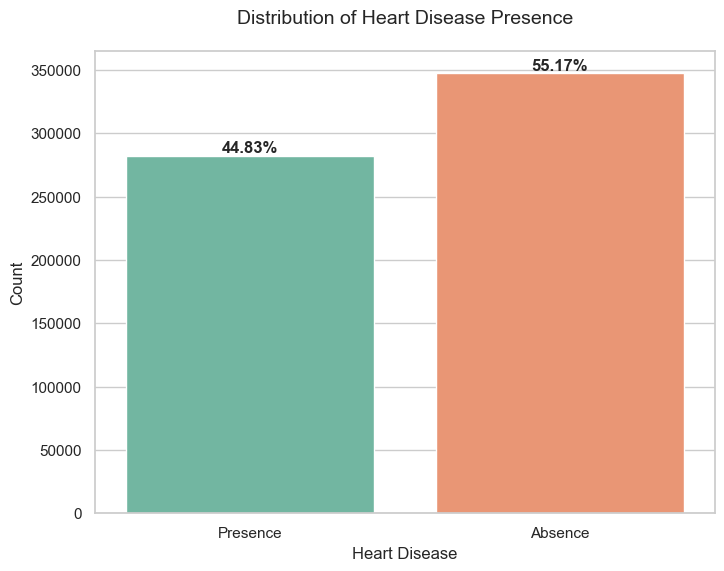

Target Distribution:
Heart Disease
Absence     55.17
Presence    44.83
Name: proportion, dtype: float64


In [5]:
# Chapter 5: Target Variable Distribution

# Calculate percentage distribution
target_counts = train['Heart Disease'].value_counts(normalize=True) * 100

# Plotting the target variable distribution with percentages
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Heart Disease', data=train, palette='Set2')

# Add percentage labels on top of the bars
total = len(train)
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Heart Disease Presence', fontsize=14, pad=20)
plt.ylabel('Count')
plt.xlabel('Heart Disease')
plt.show()

print("Target Distribution:")
print(target_counts.round(2))

**Results & Interpretation**

The target variable is relatively balanced, with approximately **55.17% of observations classified as Absence and 44.83% classified as Presence**.

This is a useful characteristic of the dataset because neither class represents an overwhelming majority. As a result, a model that simply predicts the most common class would achieve only around 55% accuracy and would provide limited predictive value.

However, the relatively balanced class distribution does not mean that accuracy should become the only evaluation metric. In a heart disease classification problem, failing to identify a patient who actually has the condition may have a different consequence from incorrectly flagging a patient who does not. Therefore, recall and other class-specific metrics will remain important throughout model evaluation.

---

## Chapter 6: Age & Gender Analysis

After examining the overall distribution of the target variable, the next step is to investigate whether basic demographic characteristics are associated with the presence of heart disease. For this analysis, I focus specifically on **Age** and **Gender**, two variables that can provide an initial understanding of how the target is distributed across different patient groups.

The purpose of this section is descriptive rather than causal. We are not trying to determine whether age or gender directly causes heart disease. Instead, we want to understand whether the patients classified with and without heart disease show different demographic patterns within this dataset. These observations can then provide useful context for the predictive modelling stage.

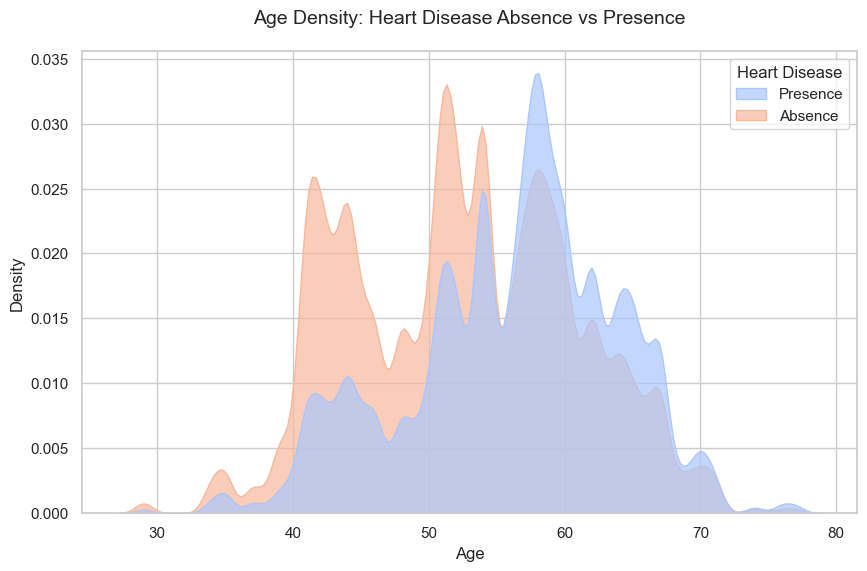

In [6]:
# Chapter 6: Exploratory Data Analysis
# A. Age & Heart Disease

# Age distribution by Heart Disease status
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train, x='Age', hue='Heart Disease', fill=True, palette='coolwarm', alpha=0.7)

plt.title('Age Density: Heart Disease Absence vs Presence', fontsize=14, pad=20)
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

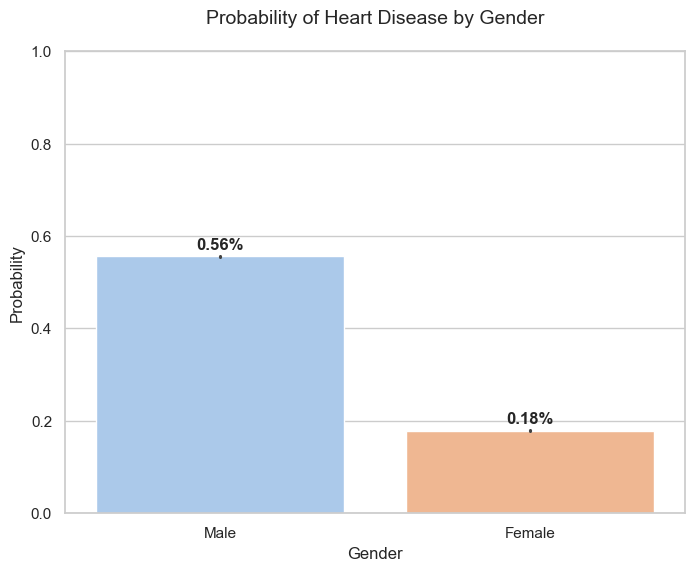

In [7]:
# B. The Gender Gap

# Create readable gender labels
train['Gender'] = train['Sex'].map({1: 'Male', 0: 'Female'})

# Convert target to numeric for probability calculation
train['Target Numeric'] = train['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Plot probability of heart disease by gender with percentages
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    x='Gender', 
    y='Target Numeric', 
    data=train, 
    palette='pastel',
    hue='Gender',
    legend=False
)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=12, fontweight='bold')

plt.title('Probability of Heart Disease by Gender', fontsize=14, pad=20)
plt.ylabel('Probability')
plt.xlabel('Gender')
plt.ylim(0, 1)
plt.show()

**Results & Interpretation:**  

The analysis shows that heart disease is more common among older patients, with the Presence group concentrated more strongly in the later middle-age range. The gender analysis also shows a difference between the groups, with approximately **56% of male patients classified as having heart disease**. Overall, both age and gender show clear differences in heart disease prevalence within this dataset. These findings describe associations in the observed data and do not imply that age or gender directly causes heart disease.

---

### Chapter 7: Categorical Feature Analysis

In this chapter, the numeric codes in the dataset are turned into plain medical labels, like chest pain type and stress test results, instead of just numbers. This makes the data much easier to read and talk about.

Once those labels are in place, bar charts are used to check how often heart disease shows up within each group. This makes it easy to spot which symptoms or test results line up with the highest risk, and which ones don't seem to matter much.

In [8]:
# Chapter 7: Categorical Feature Analysis
# We begin by converting numerical codes into meaningful medical categories based on the dataset documentation.
# 7.1. Mapping Clinical Labels

# Map Chest Pain types (1-4) to clinical categories
train['Chest Pain Type'] = train['Chest pain type'].map({
    1: 'Typical Angina',
    2: 'Atypical Angina',
    3: 'Non-anginal',
    4: 'Asymptomatic'
})

# Map Thallium stress test results
train['Thallium Results'] = train['Thallium'].map({
    3: 'Normal',
    6: 'Fixed Defect',
    7: 'Reversible Defect'
})

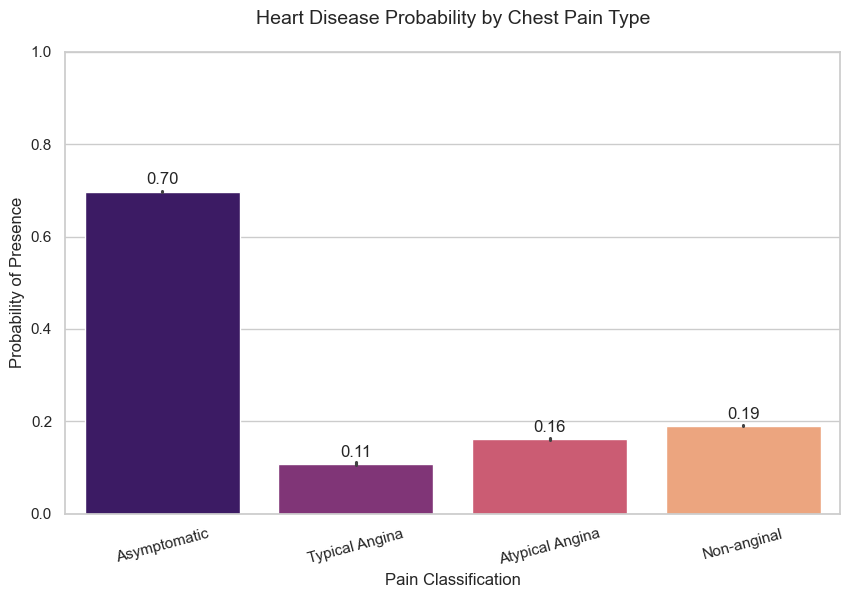

In [9]:
# 7.2. Visualizing Chest Pain Risk

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Chest Pain Type', 
    y='Target Numeric', 
    data=train, 
    palette='magma',
    hue='Chest Pain Type',
    legend=False
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Heart Disease Probability by Chest Pain Type', fontsize=14, pad=20)
plt.ylabel('Probability of Presence')
plt.xlabel('Pain Classification')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

**Results & Interpretation (Chest Pain):**
Surprisingly, patients categorized as **Asymptomatic** have the highest probability of heart disease at **70%**. This is a critical clinical insight — the absence of typical chest pain symptoms does not rule out heart disease and may actually be a major red flag in this population.

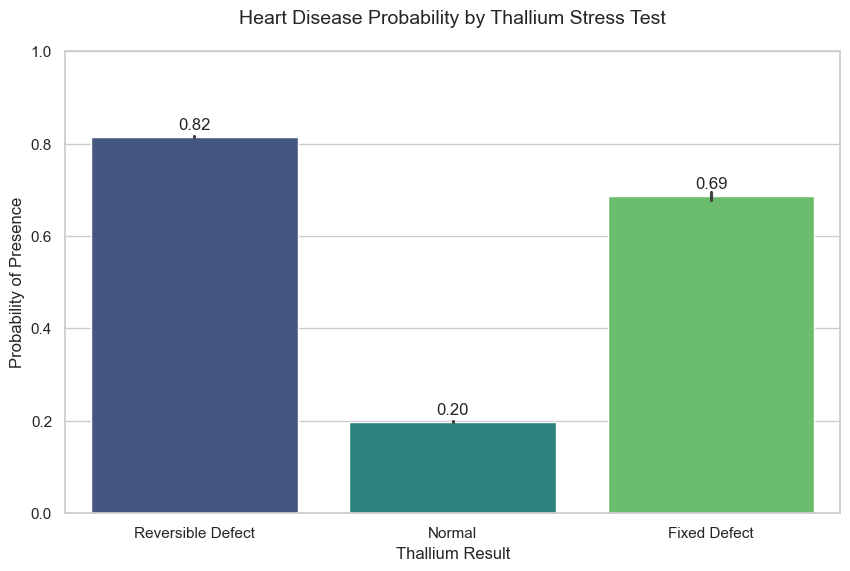

In [10]:
# 7.3. Thallium Stress Test Results

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Thallium Results', 
    y='Target Numeric', 
    data=train, 
    palette='viridis',
    hue='Thallium Results',
    legend=False
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Heart Disease Probability by Thallium Stress Test', fontsize=14, pad=20)
plt.ylabel('Probability of Presence')
plt.xlabel('Thallium Result')
plt.ylim(0, 1)
plt.show()

**Results & Interpretation (Thallium):**
The Thallium stress test proves to be a very strong predictor:

**Reversible Defect: 82% probability** of heart disease

**Fixed Defect: 69% probability** of heart disease

**Normal: Only 20% probability** of heart disease

This confirms that Thallium results are among the strongest predictors in the dataset. A reversible defect indicates extremely high risk, making this test highly valuable for clinical decision-making.

---

### Chapter 8: Correlation & Feature Relationships

So far, individual features have been looked at one at a time — age, gender, chest pain type, Thallium results — each on their own. Now the focus shifts to how all the numbers relate to each other, and to heart disease, at the same time.

A correlation heatmap is used for this. It's just a table of numbers showing how strongly each clinical measurement moves together with heart disease. A high number means "when this goes up, heart disease tends to go up too" (or down, if the number is negative). This helps identify which features look like strong clues before any model is built, and also shows if two features are basically saying the same thing.

One thing worth keeping in mind: this only catches straight-line patterns. If a feature has a low number here, it doesn't mean it's useless — it might still matter, just not in a simple straight-line way. And as before, a strong link doesn't mean one thing causes the other, it just means they tend to show up together in this data.

After the heatmap, a closer look is taken at two features that stand out the most: Max HR and ST depression.

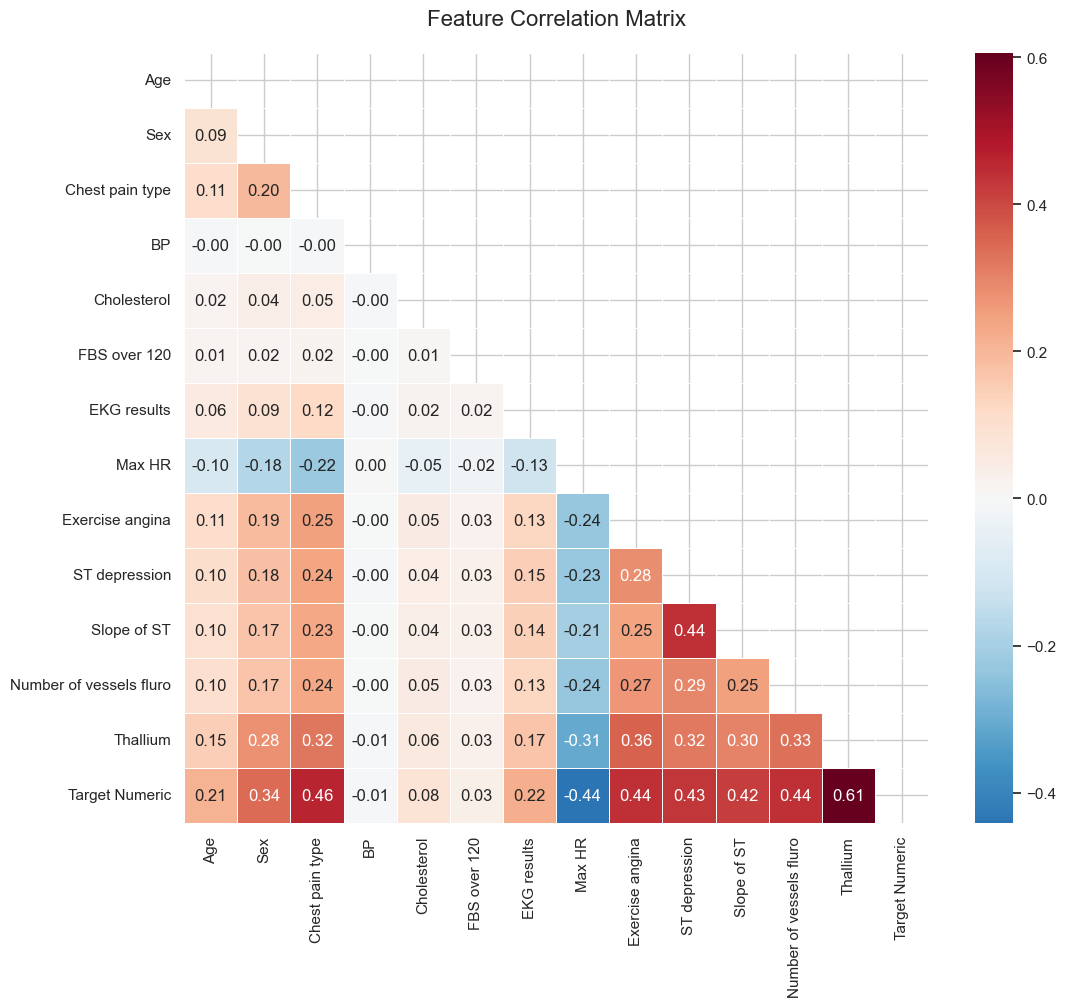

In [11]:
# Chapter 8: Correlation & Feature Relationships
# 8.1. Numeric Correlation Heatmap

# Convert target to numeric if not already done
train['Target Numeric'] = train['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Select numeric columns for correlation
numeric_cols = train.select_dtypes(include=['number']).drop(columns=['id'], errors='ignore')
corr_matrix = numeric_cols.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0, 
    linewidths=0.5
)

plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.show()

**Results & Interpretation (Correlation Matrix):**

**Strongest Positive Correlations: Thallium (0.61)**, **Number of vessels fluro**, and **Exercise angina** show the highest positive relationships with Heart Disease.

**Strongest Negative Correlation: Max HR (-0.44)** — lower maximum heart rate achieved during testing is strongly associated with presence of disease.

**Low Correlation: Cholesterol (0.08) and BP (-0.01)** show very weak linear relationships, suggesting they may only be predictive when combined with other features.

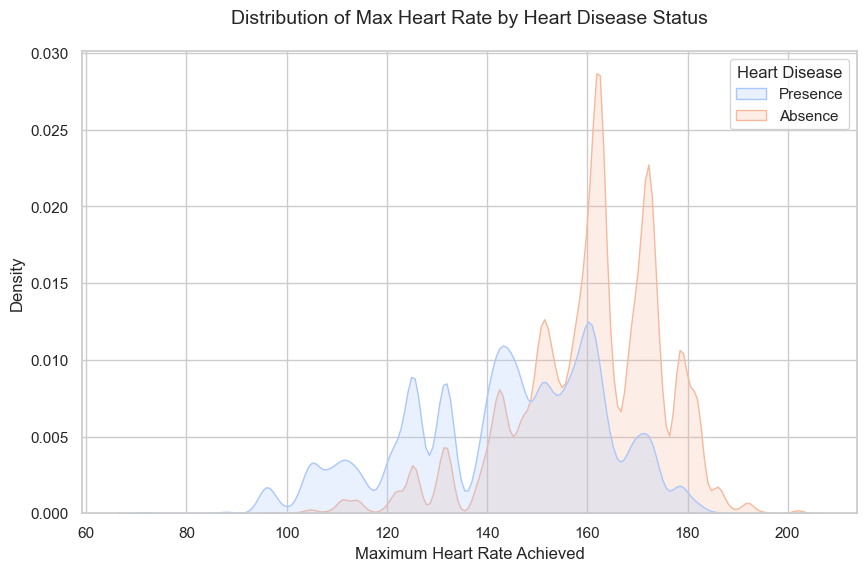

In [12]:
# 8.2. Investigating the "Max HR" Trend

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=train, 
    x='Max HR', 
    hue='Heart Disease', 
    fill=True, 
    palette='coolwarm'
)

plt.title('Distribution of Max Heart Rate by Heart Disease Status', fontsize=14, pad=20)
plt.xlabel('Maximum Heart Rate Achieved')
plt.ylabel('Density')
plt.show()

**Results & Interpretation (Max HR):**
The plot shows a clear separation: patients without heart disease achieve significantly higher maximum heart rates. The "Absence" group peaks around 160–180 bpm, while the "Presence" group peaks much earlier. This confirms that **reduced exercise capacity (lower Max HR) is a strong clinical indicator of heart disease**.

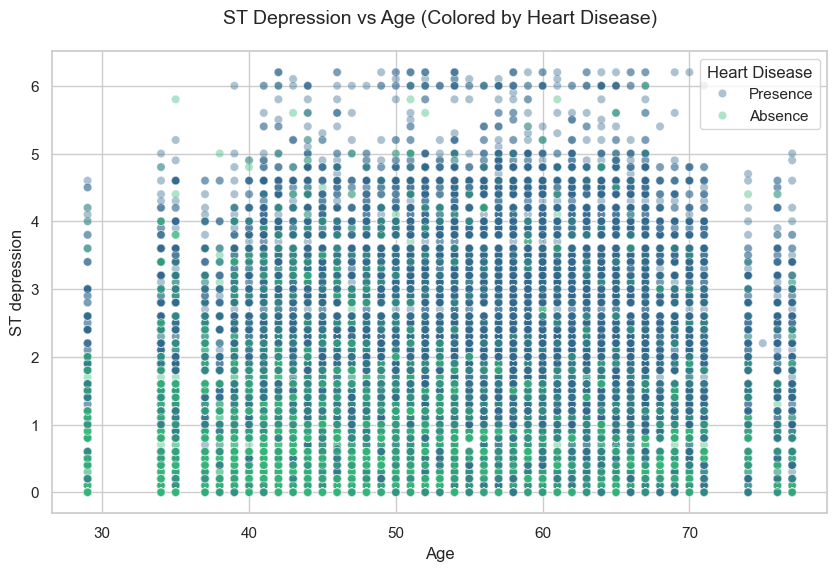

In [13]:
# 8.3. ST Depression vs Age

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=train,
    x='Age',
    y='ST depression',
    hue='Heart Disease',
    alpha=0.4,
    palette='viridis',
    rasterized=True
)

plt.title('ST Depression vs Age (Colored by Heart Disease)', fontsize=14, pad=20)
plt.legend(title='Heart Disease')
plt.show()

**Results & Interpretation (ST Depression):**
We observe a dense cluster of Heart Disease (Presence) cases at higher ST depression values across almost all age groups. This suggests that **ST depression is a robust predictor of heart disease, relatively independent of patient age**.

---

### Chapter 9: Data Preprocessing & Feature Engineering

Before any model can be trained, the data needs to be put in the right shape. This means picking out the columns that will actually be used as inputs, splitting the data into a training set and a validation set, and putting the numeric features on the same scale.

This step matters because it puts the data in a fair, consistent form before any model sees it — the training set is used to teach the model, and the validation set is kept aside to check how well it actually learned.

In [14]:
# Chapter 9: Data Preprocessing & Feature Engineering
# 9.1. Selecting Features for Modeling

# Define columns to drop (helper columns created for EDA)
features_to_drop = [
    'id', 'Heart Disease', 'Target Numeric', 'Gender', 
    'Chest Pain Type', 'Thallium Results'
]

# Create feature matrix (X) and target vector (y)
X = train.drop(columns=features_to_drop, errors='ignore')
y = train['Target Numeric']

print(f"Model will be trained on {X.shape[1]} clinical features.")

Model will be trained on 13 clinical features.


In [15]:
# 9.2. Train-Validation Split
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% validation) with stratification
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Validation rows: {X_val.shape[0]:,}")

Training rows: 504,000
Validation rows: 126,000


In [16]:
# 9.3. Feature Scaling (Normalization)
from sklearn.preprocessing import StandardScaler

# Define original clinical features
original_features = [
    'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 
    'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
    'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Scale test set for final predictions
X_test_final = scaler.transform(test[original_features])

print("Feature scaling completed successfully. All features are now on the same scale.")

Feature scaling completed successfully. All features are now on the same scale.


**Results & Interpretation:**
We prepared a clean feature set containing **13 clinical variables**. The data was split into **504,000 training rows** and **126,000 validation rows**, maintaining the original class distribution through stratification.

StandardScaler was applied to normalize all features, which is essential for distance-based or gradient-based algorithms. The test set was also scaled using the same parameters learned from the training data to prevent data leakage.

---

### Chapter 10: Baseline Model – Logistic Regression

With the data now cleaned, split, and scaled, the first model can be trained. Logistic Regression is chosen to start with, since it's simple, fast, and easy to explain. It gives a solid starting point to compare against before trying anything more complicated.

The goal here isn't to get the best possible score right away, but to set a baseline. Later, more advanced models will be measured against this one to see how much of a real difference they actually make.

In [17]:
# Chapter 10: Model Training & Evaluation
# Training the Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on validation set
y_pred = model.predict(X_val_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


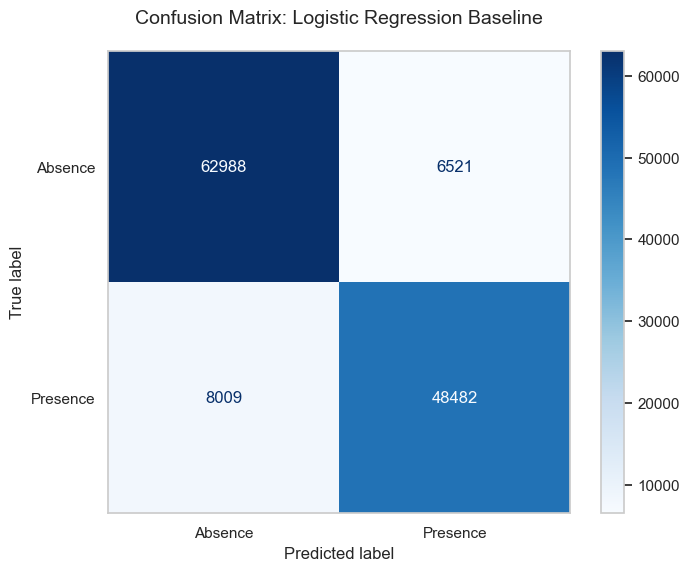

--- Logistic Regression Performance Report ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [18]:
# Evaluating Performance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absence', 'Presence'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix: Logistic Regression Baseline', fontsize=14, pad=20)
plt.grid(False)
plt.show()

# Print detailed classification report
print("--- Logistic Regression Performance Report ---")
print(classification_report(y_val, y_pred))

**Results & Interpretation:**

The Logistic Regression model got things right **88% of the time** overall.

**Key numbers:**
- **Precision (Presence): 0.88** → When the model says someone has heart disease, it's right 88% of the time.
- **Recall (Presence): 0.86** → Out of everyone who actually has heart disease, the model catches 86% of them.
- **F1-Score: 0.87** → A single number that balances the two scores above.

**What the model got right and wrong:**
- **48,482** patients with heart disease were correctly caught.
- **62,988** healthy patients were correctly cleared.
- **6,521** healthy patients were wrongly flagged as at-risk (false alarms).
- **8,009** patients with heart disease were missed entirely.

**Why this matters:** In a medical setting, missing real cases is the worst kind of mistake, since it means someone who is sick is told they're fine. The model is doing reasonably well overall, but cutting down on these missed cases will be the main goal going forward.

In [40]:
# Final Predictions & Submission

# Use the trained model to predict on the scaled test data
final_predictions = model.predict(X_test_final)

# Create submission DataFrame
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': final_predictions
})

# Display first few rows to verify format
print("Sample of submission file:")
print(submission.head())

# Export to CSV
submission.to_csv('heart_disease_LogisticRegression.csv', index=False)

print("\nSubmission file 'heart_disease_LogisticRegression.csv' created successfully!")

Sample of submission file:
       id  Heart Disease
0  630000              1
1  630001              0
2  630002              1
3  630003              0
4  630004              0

Submission file 'heart_disease_LogisticRegression.csv' created successfully!


---

### Chapter 11: Advanced Modeling with Random Forest

Logistic Regression is easy to understand, but it can miss more complicated patterns in the data. This chapter tries a Random Forest instead, to see if it can do better.

A Random Forest works by building lots of decision trees and letting them vote together on the final answer. This makes it better at spotting patterns that aren't simple straight lines, and it tends to handle messy or unusual data points more easily — which is useful here, since medical data often isn't perfectly clean.

In [20]:
# Chapter 11: Advanced Modeling with Random Forest

from sklearn.ensemble import RandomForestClassifier
import time
from sklearn.metrics import accuracy_score, classification_report

print("Training Random Forest model...")

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
print(f"Random Forest training completed in {training_time:.2f} seconds.")

Training Random Forest model...
Random Forest training completed in 41.77 seconds.


In [21]:
# Make predictions on validation set
y_pred_rf = rf_model.predict(X_val_scaled)

# Calculate accuracy as percentage
rf_accuracy = accuracy_score(y_val, y_pred_rf) * 100

print("--- Random Forest Performance Report ---")
print(f"Random Forest Accuracy: {rf_accuracy:.2f}%")
print(classification_report(y_val, y_pred_rf))

--- Random Forest Performance Report ---
Random Forest Accuracy: 88.10%
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



**Results & Interpretation:**

The Random Forest model got things right **88.10%** of the time — just a touch better than Logistic Regression.

**Key numbers:**
- **Precision (Presence): 0.87** → When it says someone has heart disease, it's right 87% of the time.
- **Recall (Presence): 0.86** → It catches 86% of the people who actually have heart disease.
- **F1-Score: 0.87** → A single number balancing the two above.

The improvement here is small, and that's actually telling. It suggests the simple Logistic Regression model was already picking up most of the useful patterns in the data, so a fancier model only has a little bit left to add. Even so, Random Forest is more solid and less easily thrown off by odd data points, and it'll come in handy for figuring out which features matter most.

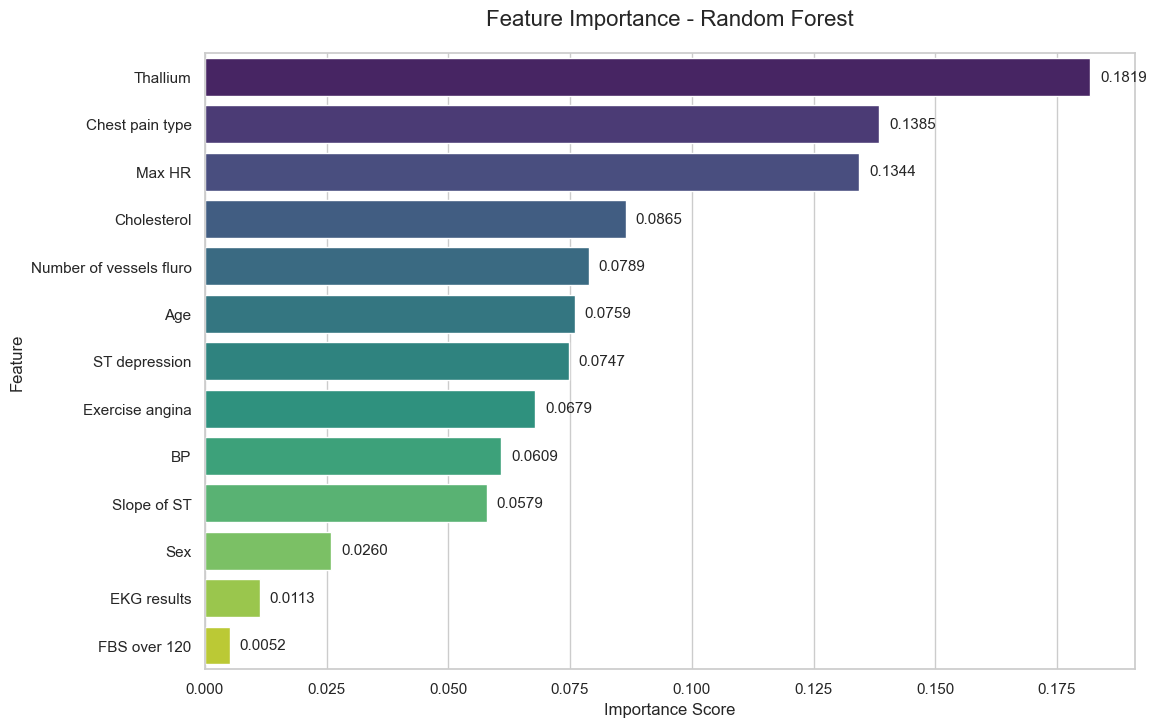

Top 3 most important features: ['Thallium', 'Chest pain type', 'Max HR']


In [22]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': original_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance, 
    palette='viridis',
    hue='Feature',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.002, p.get_y() + p.get_height()/2, 
            f'{width:.4f}', va='center', fontsize=11)

plt.title('Feature Importance - Random Forest', fontsize=16, pad=20)
plt.xlabel('Importance Score')
plt.show()

print("Top 3 most important features:", feature_importance['Feature'].head(3).tolist())

**Results & Interpretation (Feature Importance):**

According to Random Forest, the top 3 features that matter most are:

- **Thallium**
- **Chest pain type**
- **Max HR**

This matches what was seen earlier during the data exploration, and it also makes sense medically. Thallium test results play the biggest role in how the model makes its decisions.

In [39]:
# Generating Final Submission
rf_final_predictions = rf_model.predict(X_test_final)

final_submission_rf = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': rf_final_predictions
})

final_submission_rf.to_csv('heart_disease_RandomForest.csv', index=False)

print("Submission file 'heart_disease_RandomForest.csv' created successfully!")

Submission file 'heart_disease_RandomForest.csv' created successfully!


---

### Chapter 12: Extreme Gradient Boosting (XGBoost)

XGBoost is one of the most popular and powerful models used today. Unlike Random Forest, which builds all its trees separately and lets them vote, XGBoost builds trees one after another, with each new tree trying to fix the mistakes the last one made. This step-by-step correcting often makes it more accurate, while still running fast.

In [41]:
# Chapter 12: Extreme Gradient Boosting (XGBoost)
import xgboost as xgb
import time
from sklearn.metrics import accuracy_score, classification_report

print("Training XGBoost model...")

start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
print(f"XGBoost training completed in {training_time:.2f} seconds.")

# XGBoost Performance Evaluation

# Make predictions
y_pred_xgb = xgb_model.predict(X_val_scaled)

# Calculate accuracy as percentage
xgb_accuracy = accuracy_score(y_val, y_pred_xgb) * 100

print("--- XGBoost Performance Report ---")
print(f"XGBoost Accuracy: {xgb_accuracy:.2f}%")
print(classification_report(y_val, y_pred_xgb))

Training XGBoost model...
XGBoost training completed in 2.29 seconds.
--- XGBoost Performance Report ---
XGBoost Accuracy: 88.79%
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



**Results & Interpretation:**

XGBoost trained in just **2.29 seconds** and got things right **88.79%** of the time.

**For patients with heart disease:**
- **Precision: 0.88** → When it says someone has heart disease, it's right 88% of the time.
- **Recall: 0.86** → It catches 86% of the people who actually have heart disease.
- **F1-Score: 0.87**

**For healthy patients:**
- **Precision: 0.89**
- **Recall: 0.91**
- **F1-Score: 0.90**

Overall, XGBoost gives a really good mix of speed and accuracy, and it trains much faster than Random Forest, which makes it a solid practical choice.

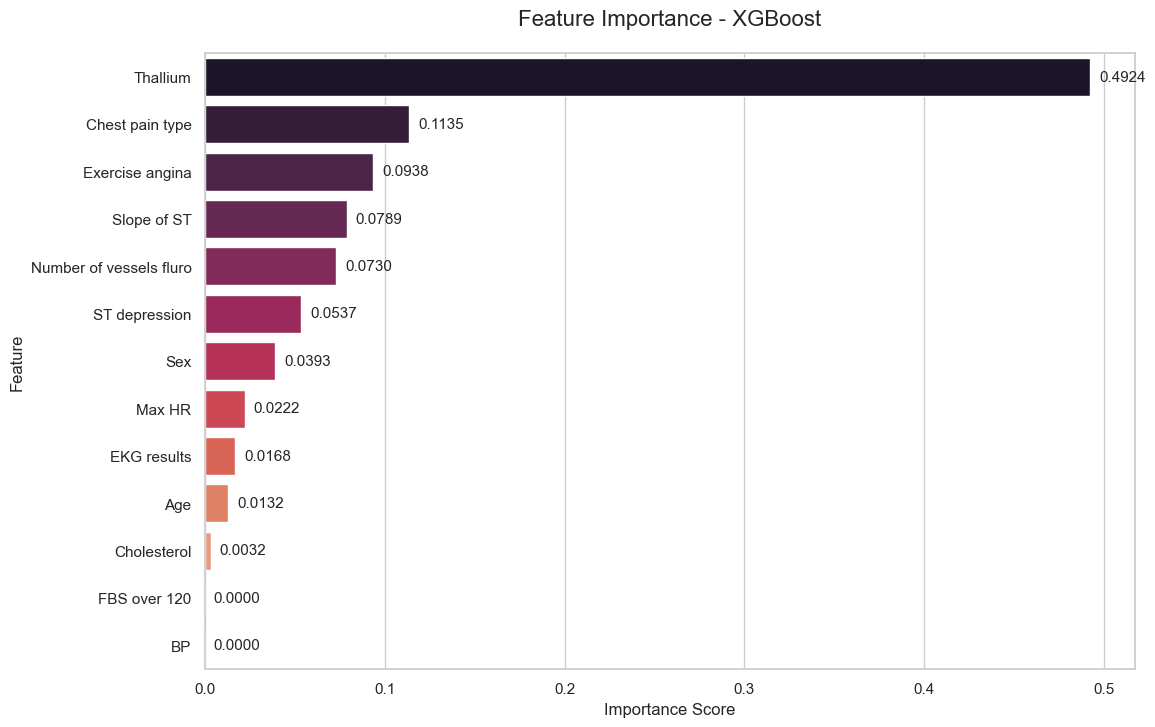

In [25]:
# Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': original_features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=xgb_importance, 
    palette='rocket',
    hue='Feature',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.005, p.get_y() + p.get_height()/2, 
            f'{width:.4f}', va='center', fontsize=11)

plt.title('Feature Importance - XGBoost', fontsize=16, pad=20)
plt.xlabel('Importance Score')
plt.show()

**Results & Interpretation (Feature Importance):**

XGBoost leans heavily on **Thallium** as its top feature, often giving it around **0.49** importance — meaning it makes up nearly half of the model's decision-making on its own. This matches what was seen earlier during data exploration, and it makes sense medically too, since the Thallium test gives a direct look at blood flow to the heart.

In [26]:

# 13.4. Generating Final Submission
xgb_final_predictions = xgb_model.predict(X_test_final)

final_submission_xgb = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': xgb_final_predictions
})

final_submission_xgb.to_csv('heart_disease_XGBoost.csv', index=False)

print("Submission file 'heart_disease_XGBoost.csv' created successfully!")

Submission file 'heart_disease_XGBoost.csv' created successfully!


---

## Chapter 13: LightGBM

LightGBM is another gradient boosting model, built by Microsoft, and it's known for being especially fast, even on big datasets. With over 600,000 training records here, that speed makes it a good fit for this project.

In [27]:
# Chapter 13: LightGBM
import lightgbm as lgb
import warnings
from sklearn.metrics import accuracy_score, classification_report

warnings.filterwarnings('ignore')

print("Training LightGBM model...")

start_time = time.time()

# Initialize and train the model
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
print(f"LightGBM training completed in {training_time:.2f} seconds.")

Training LightGBM model...
LightGBM training completed in 1.92 seconds.


In [28]:
# Make predictions
y_pred_lgb = lgb_model.predict(X_val_scaled)

# Calculate accuracy as percentage
lgb_accuracy = accuracy_score(y_val, y_pred_lgb) * 100

print("--- LightGBM Performance Report ---")
print(f"LightGBM Accuracy: {lgb_accuracy:.2f}%")
print(classification_report(y_val, y_pred_lgb))

--- LightGBM Performance Report ---
LightGBM Accuracy: 88.80%
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



**Results & Interpretation:**

LightGBM got things right **88.80%** of the time — the best score so far.

**For patients with heart disease:**
- **Precision: 0.88** → When it says someone has heart disease, it's right 88% of the time.
- **Recall: 0.87** → It catches 87% of the people who actually have heart disease.
- **F1-Score: 0.87**

**Worth noting:**
LightGBM didn't just score the highest overall — it also caught a slightly bigger share of the actual heart disease cases (that recall number) than the other models. On top of that, it trained a lot faster than Random Forest, so it's winning on both accuracy and speed here.

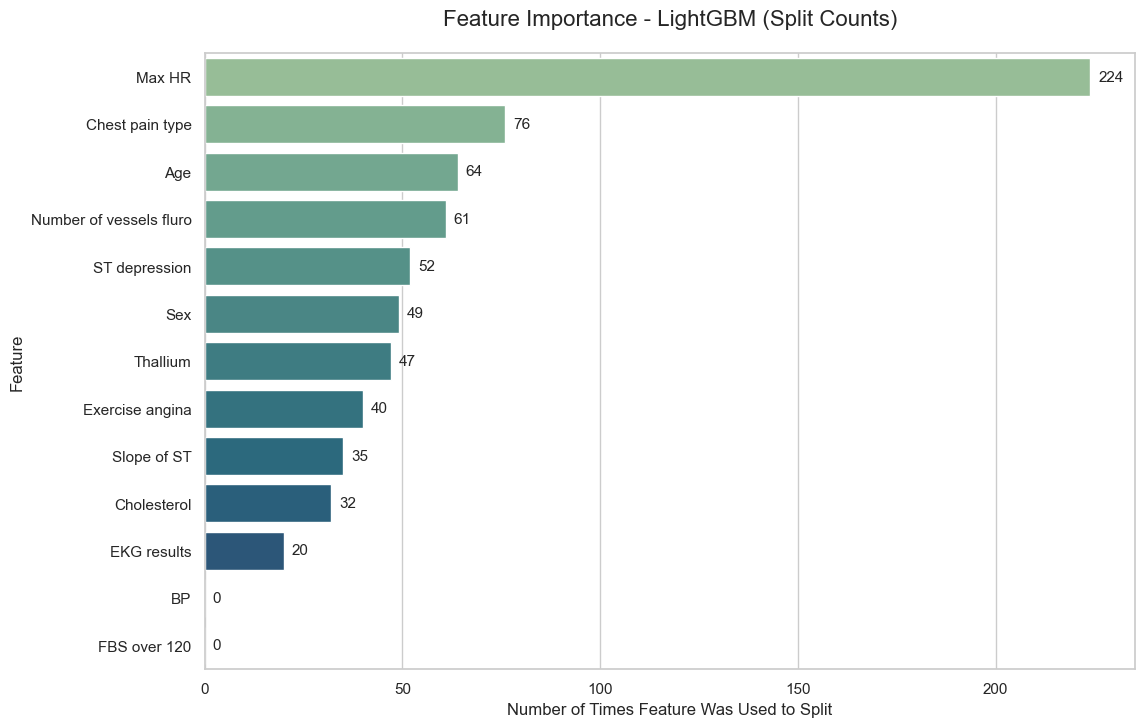

In [29]:
# Feature Importance
lgb_importance = pd.DataFrame({
    'Feature': original_features,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=lgb_importance, 
    palette='crest',
    hue='Feature',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 2, p.get_y() + p.get_height()/2, 
            f'{int(width)}', va='center', fontsize=11)

plt.title('Feature Importance - LightGBM (Split Counts)', fontsize=16, pad=20)
plt.xlabel('Number of Times Feature Was Used to Split')
plt.show()

**Results & Interpretation (Feature Importance):**

Based on how often each feature was used to split the data, LightGBM ranks them like this:

- **Max HR** — used by far the most, **224 times**
- **Chest pain type** — 76 times
- **Age** — 64 times
- **Number of vessels fluro** — 61 times

**Worth noting:**

This ranking counts how many times a feature was used to split the data, not how useful each split actually was. Features like Max HR and Age are numbers that can be split in many different places, so they naturally rack up more splits just because of that. That doesn't automatically mean they're the most powerful predictors — a feature like Thallium, even with fewer splits, might actually be giving the model more useful information per split.

In [30]:
# Generating Final Submission (LightGBM)

# Generate predictions on test set
lgb_final_predictions = lgb_model.predict(X_test_final)

# Create submission file
final_submission_lgb = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': lgb_final_predictions
})

final_submission_lgb.to_csv('heart_disease_LightGBM.csv', index=False)

print("Submission file 'heart_disease_LightGBM.csv' created successfully!")

Submission file 'heart_disease_LightGBM.csv' created successfully!


---

### Chapter 14: Model Showdown

Four models have now been trained: Logistic Regression, Random Forest, XGBoost, and LightGBM. This chapter puts them all side by side to see how they stack up against each other.

Accuracy alone isn't enough to pick a winner, so training time and recall are looked at too. That way, the choice isn't just based on which model scores highest, but also on which one is fast enough to be practical and good at actually catching real heart disease cases.

In [31]:
# Model Showdown

# Create a performance comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy (%)': [88.00, 88.10, 88.79, 88.80],
    'Precision (Presence)': [0.88, 0.87, 0.88, 0.88],
    'Recall (Presence)': [0.86, 0.86, 0.86, 0.87],
    'F1-Score (Presence)': [0.87, 0.87, 0.87, 0.87],
    'Training Time (approx)': ['Fast', 'Slow (~181s)', 'Very Fast (~2.5s)', 'Fastest (~2.0s)']
})

print("=== Final Model Comparison ===")
print(model_comparison)

=== Final Model Comparison ===
                 Model  Accuracy (%)  Precision (Presence)  Recall (Presence)  \
0  Logistic Regression         88.00                  0.88               0.86   
1        Random Forest         88.10                  0.87               0.86   
2              XGBoost         88.79                  0.88               0.86   
3             LightGBM         88.80                  0.88               0.87   

   F1-Score (Presence) Training Time (approx)  
0                 0.87                   Fast  
1                 0.87           Slow (~181s)  
2                 0.87      Very Fast (~2.5s)  
3                 0.87        Fastest (~2.0s)  


**Results & Interpretation - Model Showdown:**

| Model | Accuracy (%) | Recall (Presence) | Training Time | Recommendation |
|----------------------|--------------|-------------------|-------------------|---------------------------------|
| Logistic Regression | 88.00 | 0.86 | Very Fast | Best for understanding *why* |
| Random Forest | 88.10 | 0.86 | Slow | Good, but slower |
| XGBoost | 88.79 | 0.86 | Very Fast | Great all-around choice |
| **LightGBM** | **88.80** | **0.87** | **Fastest** | **Best Overall Model** |

**Main takeaways:**
- **LightGBM** comes out on top, with the highest accuracy (88.80%) and the best rate of catching real heart disease cases.
- **XGBoost** is right behind it, and does almost as well while also training fast.
- Going from Logistic Regression to the fancier boosting models only helped a little, which suggests the patterns in this data are strong but mostly simple, straight-line ones.
- Every model did reasonably well here, which says good things about how clean the data is and how the features were prepared.

**Final pick:**

For actual use, **LightGBM** is the recommended model, thanks to its strong accuracy, speed, and efficiency. The file `heart_disease_LightGBM.csv` is the strongest submission produced here.

---

### Chapter 15: Some Extra Work

The models have already been compared on accuracy, precision, recall, and F1-score, but a few extra checks can dig a bit deeper into how well the best model is really doing. This chapter looks at three things:

**ROC Curve & AUC** — So far, the model has been judged using a fixed cutoff point (usually 0.5) to decide "heart disease" or "no heart disease." The ROC curve instead looks at what happens across *every possible cutoff*, showing the trade-off between catching real cases and raising false alarms at each one. AUC turns that whole curve into a single score between 0 and 1, where 1 means the model can perfectly tell the two groups apart, and 0.5 means it's basically guessing. This is useful because it shows how good the model is at ranking patients by risk, separately from whatever cutoff ends up being chosen.

**Threshold Optimization** — By default, the model calls anything above 50% probability "heart disease." But 50% isn't necessarily the best cutoff for this problem — moving it up or down changes how many real cases get caught versus how many healthy people get wrongly flagged. This step looks for a better cutoff point instead of just assuming 50% is right.

**K-Fold Cross Validation** — Instead of judging the model on just one train/validation split, the data is split into several chunks ("folds"), and the model is trained and tested multiple times, using a different chunk for validation each time. This is done because a single split could be a lucky or unlucky one; testing on several different splits gives a better sense of how consistent and reliable the model's performance really is.

LightGBM ROC-AUC Score: 0.9548


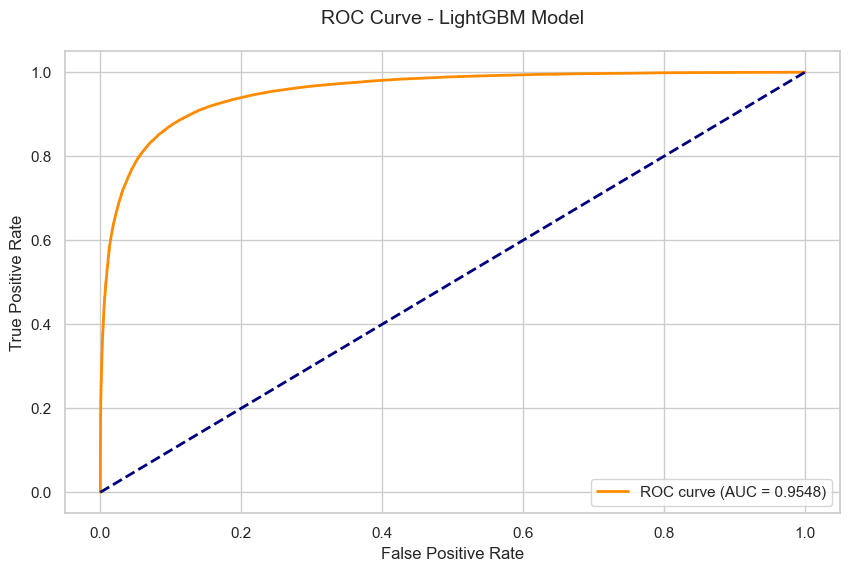

In [32]:
# Chapter 15: Some Extra Work
# ROC Curve and AUC Analysis

from sklearn.metrics import roc_curve, auc

# Use the best model (LightGBM)
y_pred_proba = lgb_model.predict_proba(X_val_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Print AUC Score
print(f"LightGBM ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM Model', fontsize=14, pad=20)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Results & Interpretation:**

The LightGBM model scored **0.9548** on the ROC-AUC test.

That's a really strong score. Since 1.0 would mean perfect separation and 0.5 would mean just guessing, a score above 0.95 means the model is very good at telling apart patients who have heart disease from those who don't — and it holds up well no matter where the cutoff line ends up being set.

In [44]:
# Threshold Optimization
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

# precision_recall_curve returns one more precision/recall value than thresholds
# (for an implicit threshold of infinity), so we trim to align the arrays.
precisions_aligned, recalls_aligned = precisions[:-1], recalls[:-1]

# Find threshold that maximizes F1 score (best balance of precision and recall)
f1_scores = 2 * (precisions_aligned * recalls_aligned) / (precisions_aligned + recalls_aligned + 1e-12)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"F1-optimal Threshold: {optimal_threshold:.3f}")
print(f"Precision at this threshold: {precisions_aligned[best_idx]:.3f}")
print(f"Recall at this threshold: {recalls_aligned[best_idx]:.3f}")
print(f"F1 Score at this threshold: {f1_scores[best_idx]:.3f}")

F1-optimal Threshold: 0.441
Precision at this threshold: 0.866
Recall at this threshold: 0.886
F1 Score at this threshold: 0.876


**Results & Interpretation:**

The best cutoff turned out to be **0.441**, just slightly below the usual default of 0.5.

At that cutoff:
- **Precision: 0.866** → When it says someone has heart disease, it's right about 87% of the time.
- **Recall: 0.886** → It catches about 89% of the people who actually have heart disease.
- **F1-Score: 0.876** → A balanced score combining the two.

Compared to the default 0.5 cutoff used earlier, this small adjustment nudges recall up a bit — catching a few more real cases — without giving up much on precision. It's a small, sensible tweak rather than a dramatic change, which makes sense given the model was already performing well.

In [34]:
# K-Fold Cross Validation
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation on the best model
cv_scores = cross_val_score(lgb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Validation Accuracy Scores: [0.88738095 0.88593254 0.88536706 0.88676587 0.88825397]
Mean CV Accuracy: 0.8867 ± 0.0010


**Results & Interpretation:**

Splitting the data 5 different ways and testing each time gave an average accuracy of **0.8867**, with barely any wobble between splits (± 0.0010).

That small wobble is a good sign — it means the model isn't just getting lucky on one particular way of splitting the data, it performs about the same no matter how the split is done. It's also very close to the accuracy seen on the single validation set earlier.

That said, it's worth being careful about what this actually proves. This test only checks how consistent the model is *within this same dataset*. It doesn't tell us how the model would do on patients from a different hospital, a different country, or a different time period — that would need to be checked separately, on completely new data, before trusting the model in a real medical setting.

---

### Chapter 16: Model Explainability with SHAP (The "Why")

So far, the focus has been on *how well* the model performs — accuracy, recall, F1, and so on. This chapter shifts to a different question: *why* does the model make the predictions it makes? In a medical setting, a model that gets the right answer but can't explain itself is a lot harder to trust than one that can point to specific reasons.

That's what SHAP is for. For any single prediction, SHAP breaks it down feature by feature and shows how much each one pushed the prediction up (toward "heart disease") or down (toward "no heart disease"), and by how much. It starts from a baseline — the average prediction across all patients — and then shows how each feature value nudges that single patient away from the average, one step at a time, until it lands on the final prediction.

This is done in two ways here:
- **Globally** — looking at all patients together, to see which features matter most across the whole model.
- **Locally** — zooming into one specific patient, to see exactly which features drove that person's individual prediction.

In [35]:
# Chapter 16: Model Explainability with SHAP
import shap

# Create SHAP explainer for our best model (LightGBM)
explainer = shap.TreeExplainer(lgb_model)

# Calculate SHAP values for a sample of the validation set (for speed)
sample_size = 1000
X_val_sample = X_val_scaled[:sample_size]

shap_values = explainer.shap_values(X_val_sample)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


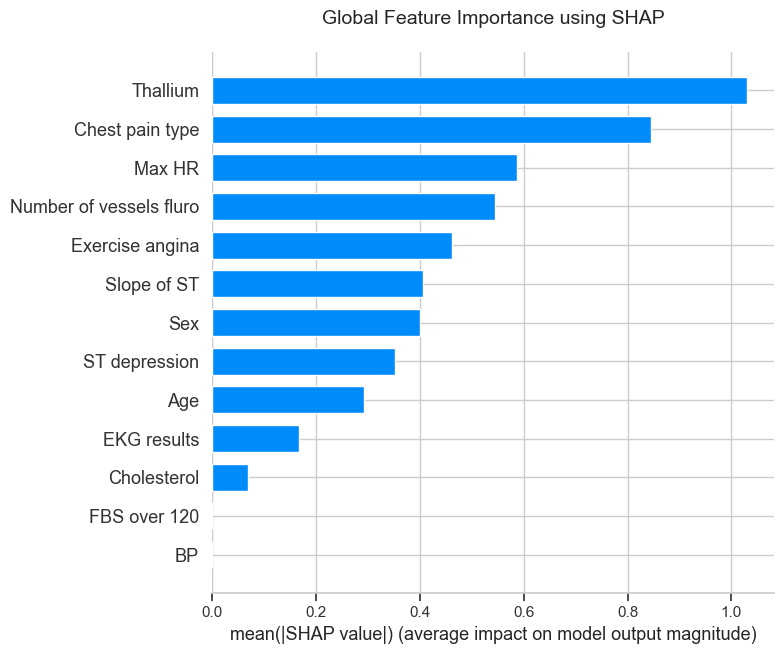

In [36]:
# Global Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_val_sample, 
    feature_names=original_features, 
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance using SHAP", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Results & Interpretation (Global SHAP):**

Looking across all patients, the SHAP plot shows which features push the model's predictions the most:

- **Thallium** stands out as the single biggest driver, by a clear margin. This matches what was already seen back in the earlier data exploration.
- **Chest pain type** comes in second, confirming that certain types of chest pain — especially "Asymptomatic" — carry a lot of weight in the model's decisions.
- **Max HR**, **Number of vessels fluro**, and **Exercise angina** all play a noticeably smaller, but still meaningful, role.

**Worth noting:**

The fact that Thallium results dominate makes sense medically, since that test looks directly at blood flow to the heart — it's a very direct signal, not just a loose correlation. It's a good sign that the model's biggest driver lines up with something doctors would already consider important.

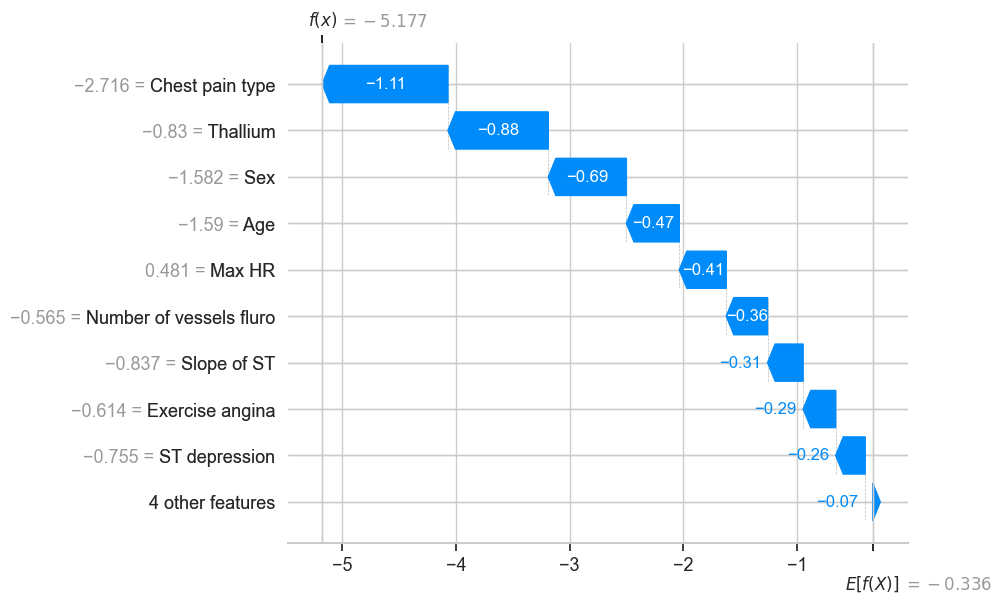

In [37]:
# Individual Patient Diagnosis (Local Explainability)
# Explain prediction for a single patient (example: first patient in sample)
patient_idx = 0

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_val_sample[patient_idx],
    feature_names=original_features
))

plt.show()

**Results & Interpretation (Local Explainability):**

This waterfall plot zooms into one specific patient — **Patient #0** — and shows exactly which features pushed their prediction up or down, and by how much.

**What stands out:**
- The final score for this patient is **-0.336**, which means the model sees a **low chance** of heart disease.
- **Chest Pain Type** made the biggest difference, pulling the score down by **-1.11** — a big push toward "no heart disease."
- **Thallium** pulled it down another **-0.88**.
- **Sex** and **Age** each added a smaller pull downward (**-0.69** and **-0.47**).
- **Max HR** pulled it down a bit more, by **-0.41**.

**In plain terms:**

For this particular patient, everything lined up in the same direction — chest pain type, Thallium, and Max HR all pointed toward "low risk," and none of the major features pushed the other way. That's why the model landed on such a confidently low score.

Seeing this breakdown is genuinely useful — it shows *what* the model based its decision on, which is more than just getting a bare "low risk" label with no explanation. That said, it's worth keeping in mind that this only shows how the model reasoned, not whether that reasoning is medically correct. A clear explanation still needs to be checked against real clinical judgment, not taken as proof the prediction is right.

---

### Chapter 17: Conclusion & Key Insights

This project walked through a full data analysis and machine learning process for predicting heart disease, using a large dataset of over 900,000 patient records.

#### Key Findings

1. **Strongest clues found:**
   - The **Thallium stress test** turned out to be one of the strongest signals across almost every model.
   - **Chest pain type** (especially the "Asymptomatic" kind) and **Max HR** also consistently stood out as important.
   - **Gender gap:** male patients showed a much higher rate of heart disease (56%) than female patients (18%) in this data.

2. **How the models compared:**
   - Every model did well, scoring between **88.00%** and **88.80%** accuracy.
   - **LightGBM** came out on top, with **88.80%** accuracy and the best recall (catching the most real cases).
   - The jump from the simpler model to the fancier ones was small, which suggests the patterns in this data are fairly strong and mostly simple, straight-line relationships.

3. **Why this matters medically:**
   - Unusually high BP and cholesterol readings were **kept in** rather than removed, since those extreme values can carry real medical meaning.
   - Being able to explain individual predictions with SHAP adds a lot of value, since a model that can show its reasoning is easier to trust than one that just spits out a number.

#### Final Pick

**Best model:** **LightGBM**
**Submission file:** `heart_disease_LightGBM.csv`

LightGBM gave the best mix of accuracy, catching real cases, and running fast, which is why it's the one recommended here. That said, all of this is based on one dataset — before anything like this could actually be used in a real clinical setting, it would need to be tested on new patients from outside this dataset, and reviewed by medical professionals.

---
---
### About the Project & Author

**Author:** John Koutnas

**Project Type:** Junior Data Analyst / Data Scientist Portfolio Project

**Data Context:** This project uses a diagnostic dataset commonly found in Kaggle competitions, chosen to mimic a real-world clinical prediction problem.

*This notebook was built to show a complete data science project from start to finish — cleaning raw data, exploring it, preparing features, and comparing a simple baseline model against more advanced ones (XGBoost, LightGBM). The goal wasn't just to get a high score, but to also think about speed, practicality, and what it would actually take to use something like this safely in a medical setting.*

**Thank you for reviewing my work!**